# Testing a unified GRB + afterglow model

An issue was found when I was reading the code for the unified GRB + afterglow model. We assumed that the GRB saturated directly and the afterglow rised during a time of T90. However, I think it is wrong. The GRB should saturate during a time of T90, and the afterglow should start to rise at a latter time and different timescale. Here I review the code and try to implement this change. I also want to test the model with some parameters and see how it behaves.

## Model for the GRB 

A simple model for the GRB would be a function that rises to a maximum value (saturation) during a time T90 and then saturates:
$$\Delta h_{\rm GRB}(t) = \begin{cases}
0 & \text{if } t < 0 \\
\Delta h_{\text{GRB}} \cdot \frac{t}{T_{90}} & \text{if } 0 \le t < T_{90} \\
\Delta h_{\text{GRB}} & \text{if } t \geq T_{90}
\end{cases}$$

## Model for the Afterglow

Here is the major correction. The afterglow should start to rise at a latter time and different timescale. 

I could use two different timescales to define:
1. The time when the afterglow starts to rise, which allow an afterglow emission to start before or after $T_{90}$ .
2. The timescale for the afterglow rise, which could be defined as the total duration of the afterglow or the time just before it reaches its maximum value - before the decay phase starts. The latter is more physical in the context of memory effect, as it represents the time when the afterglow is still rising and contributing to the memory effect (and so deposing energy in the surrounding medium) before it starts to decay (so no energy is released -> no memory effect).

From what I found in the literature, there is two timescales of interrest for the afterglow:
1. Deceleration time $t_{\text{dec}}$: represents the moment when the relativistic fireball has swept up an amount of surrounding medium comparable to its own mass, causing it to start slowing down significantly. It marks the transition from the coasting phase (constant Lorentz factor) to the deceleration phase (Blandford--McKee self-similar phase) and approximately corresponds to the peak of the afterglow light curve.
2. Jet break time $t_{\text{jet}}$: represents the moment when the relativistic jet starts to spread laterally, leading to a steepening of the afterglow light curve for all wavelenght (see https://preview-www.nature.com/articles/nature23289/figures/4). It marks the transition from an apparently isotropic emission (as the Lorentz factor  $\Gamma$ is high, the observer only sees the relativistic beaming cone of size  $1/\Gamma \ll \theta_j$) to a regime where the finite opening angle of the jet  becomes observable. When $\Gamma \sim 1/\theta_j$, the observer starts to see the  edge of the jet, causing the afterglow light curve to steepen. So I could use $t_{\text{jet}}$ as the timescale for the end afterglow rise, as it represents the time when the afterglow emission starts to decay more rapidly and the memory effect would be less important.

see [here](https://arxiv.org/pdf/astro-ph/0307525) for more details on the afterglow timescales.

The mathematical model for the afterglow could be defined as:
$$\Delta h_{\rm aft}(t) = \begin{cases}
0 & \text{if } t < t_{\text{dec}} \\
\Delta h_{\text{aft}} \cdot \frac{t - t_{\text{dec}}}{t_{\text{jet}} - t_{\text{dec}}} & \text{if } t_{\text{dec}} \le t < t_{\text{jet}} \\
\Delta h_{\text{aft}} & \text{if } t \geq t_{\text{jet}}
\end{cases}$$

And so the total memory effect would be:
$$\Delta h(t) = \Delta h_{\rm GRB}(t) + \Delta h_{\rm aft}(t)$$

The major differences with the previous model are:
1. The GRB is not anymore a constant for all times (and all frequencies), but it rises during a time T90 and then saturates. This point is in agreement with the model explained in [here](http://arxiv.org/abs/gr-qc/0405067) rather than the one for the energy injection. Also this was the model we discussed with Henri for the detectability with LISA, and so now the duration of the GRB will be of prior interrest for the detectability of the memory effect. Longer T90 (> 100 s) means that the GRB memory will drop at lower target frequencies of LISA, lowering the SNR. Adding the afterglow will increase the memory effect and so the SNR at these frequencies, so it is usefull to take into account the afterglow. 

2. A more distinct separation between the GRB and the afterglow, with different timescales for the rise of each component. If we can determine the timescales for the GRB and the afterglow, we can better understand the contribution of each component to the total memory effect and how they evolve over time. 



## Implementation

In [2]:
import numpy as np
import matplotlib.pyplot as plt
PC_SI = 3.086e16  # parsec en mètres
G_SI = 6.67430e-11  # constante gravitationnelle en m^3 kg^-1 s^-2
C_SI = 299792458  # vitesse de la lumière en m/s

In [3]:
def grb_afterglow_model(t, E_GRB, T_90, E_aft, beta, t_dec, t_jet_break, d, theta, theta_j):
    
    E_GRB *= 1e-7 # convert erg to J
    E_aft *= 1e-7 # convert erg to J
    d *= 1e6 * PC_SI # convert Mpc to m
    
    delta_h = np.zeros_like(t)
    
    # GRB contribution
    delta_h_GRB =(G_SI/C_SI**4) * (2 * E_GRB * beta**2 /d)  * (np.sin(theta)**2 / (1-(beta *np.cos(theta)))) 
    for i in range(len(t)):
        if t[i] < 0:
            delta_h[i] = 0
        elif 0 <= t[i] < T_90:
            delta_h[i] = delta_h_GRB * (t[i]/T_90)
        elif t[i] >= T_90:
            delta_h[i] = delta_h_GRB
    # Afterglow contribution
    delta_h_aft = (G_SI/C_SI**4) * (2 * E_aft * beta**2 /d)  * (np.sin(theta)**2 / (1-(beta *np.cos(theta)))) 
    for i in range(len(t)):
        if t[i] < t_dec:
            delta_h[i] += 0
        elif t_dec <= t[i] < t_jet_break:
            delta_h[i] += delta_h_aft * ((t[i]-t_dec)/(t_jet_break-t_dec))
        elif t[i] >= t_jet_break:
            delta_h[i] += delta_h_aft
    return delta_h, delta_h_GRB, delta_h_aft

t_jet_break = 1.00e+00 days
t_jet_break = 8.64e+04 seconds
dt = 8.64e+04 seconds, which is approximately 1.00 days
delta_h_GRB = 2.00e-24 delta_h_aft = 1.31e-23
         	Approximation will be used...


/home/pycbc/work/Model_perso_grb_afterglow/LISA.py:105: RuntimeWarning: overflow encountered in exp
  Sc *= np.exp(-f**alpha + beta*f*np.sin(kappa*f))
/home/pycbc/work/Model_perso_grb_afterglow/LISA.py:105: RuntimeWarning: invalid value encountered in multiply
  Sc *= np.exp(-f**alpha + beta*f*np.sin(kappa*f))


Text(0.005, 1e-20, 'LISA')

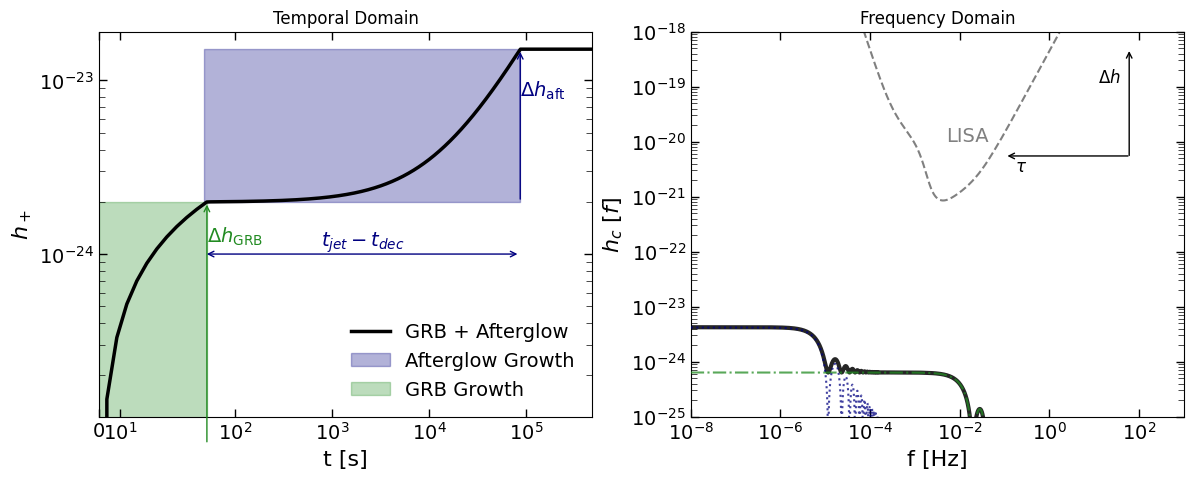

In [4]:
import utils_grb_aft_new as utils
import importlib
importlib.reload(utils)

E_grb = 7.6e51 # erg
T_90 = 51.37
d = 350*1e6  # Mpc
beta = 0.99
theta = np.deg2rad(30)  # convert degrees to radians
theta_j = np.deg2rad(0.8)  # convert degrees to radians
E_aft = 5e52# erg
t_dec = 50
t_jet_break = 86400
t = np.linspace(-1, 5.5*t_jet_break, 100000)
t_jet_break_day = t_jet_break / 86400.0  # convert seconds to days
print(f"t_jet_break = {t_jet_break_day:.2e} days")
print(f't_jet_break = {t_jet_break:.2e} seconds')
dt = t_jet_break - t_dec
print(f"dt = {dt:.2e} seconds, which is approximately {dt/86400:.2f} days")
f_obs = np.logspace(-8, 3, 10000)  

delta_h, delta_h_GRB, delta_h_aft = utils.grb_afterglow_model(t, E_grb, T_90, E_aft, beta, t_dec, t_jet_break, d, theta, theta_j)
print(f"delta_h_GRB = {delta_h_GRB:.2e}", f"delta_h_aft = {delta_h_aft:.2e}")
H_total, H_GRB, H_aft = utils.fft(f_obs, delta_h_GRB, T_90, delta_h_aft, t_dec, t_jet_break)
fig, ax = utils.plot_grb_afterglow(t, delta_h, f_obs, H_total, H_GRB, H_aft, T_90, t_dec, t_jet_break, delta_h_GRB, delta_h_aft)
ax[1].set_xlim(1e-8, 1e3)
ax[1].set_ylim(1e-25, 1e-18)

ax[0].set_xlim(0,5.5*t_jet_break)
ax[0].set_xscale('symlog', linthresh=T_90)
import LISA as li
lisa = li.LISA()

# add a big arrow in the top right corner to show the direction of increasiing delta h in frequency domain
ax[1].annotate('', xy=(6e1, 5e-19), xytext=(6e1, 5e-21), arrowprops=dict(arrowstyle='->', color='black'))
ax[1].text(1.2e1, 1e-19, r'$\Delta h$', fontsize=12, color='black', ha='left', va='bottom')

# at the node of the big arrow, add a left arrow to show the direction of increasing longer duration of the signal in the frequency domain
ax[1].annotate('', xy=(1.e-1, 5.5e-21), xytext=(6.5e1, 5.5e-21), arrowprops=dict(arrowstyle='->', color='black'))
ax[1].text(2.3e-1, 5.2e-21, r'$\tau$', fontsize=12, color='black', ha='center', va='top')

S_n = np.sqrt(f_obs * np.abs(lisa.Sn(f_obs)))
ax[1].plot(f_obs, S_n, c='grey', ls='--', label='LISA Sensitivity')
ax[1].text(5e-3, 1e-20, 'LISA', fontsize=14, color='grey')

In [5]:
def t_break(theta_j, E_aft, n):
    # Calculate the jet break time in seconds
    t_jet_break = 6.2 * ((E_aft/1e52) / (n /0.1))**(1/3) * (theta_j/0.1)**(8/3) * 3600 # convert hours to seconds
    return t_jet_break/86400
theta_j = np.deg2rad(5)  # convert degrees to radians
n = 0.1  # cm^-3
E_aft = 1e50
t_jet_break_calculated = t_break(theta_j, E_aft, n)
t_jet_break_calculated

np.float64(0.03870556751230449)

         	Approximation will be used...


/home/pycbc/work/Model_perso_grb_afterglow/LISA.py:105: RuntimeWarning: overflow encountered in exp
  Sc *= np.exp(-f**alpha + beta*f*np.sin(kappa*f))
/home/pycbc/work/Model_perso_grb_afterglow/LISA.py:105: RuntimeWarning: invalid value encountered in multiply
  Sc *= np.exp(-f**alpha + beta*f*np.sin(kappa*f))


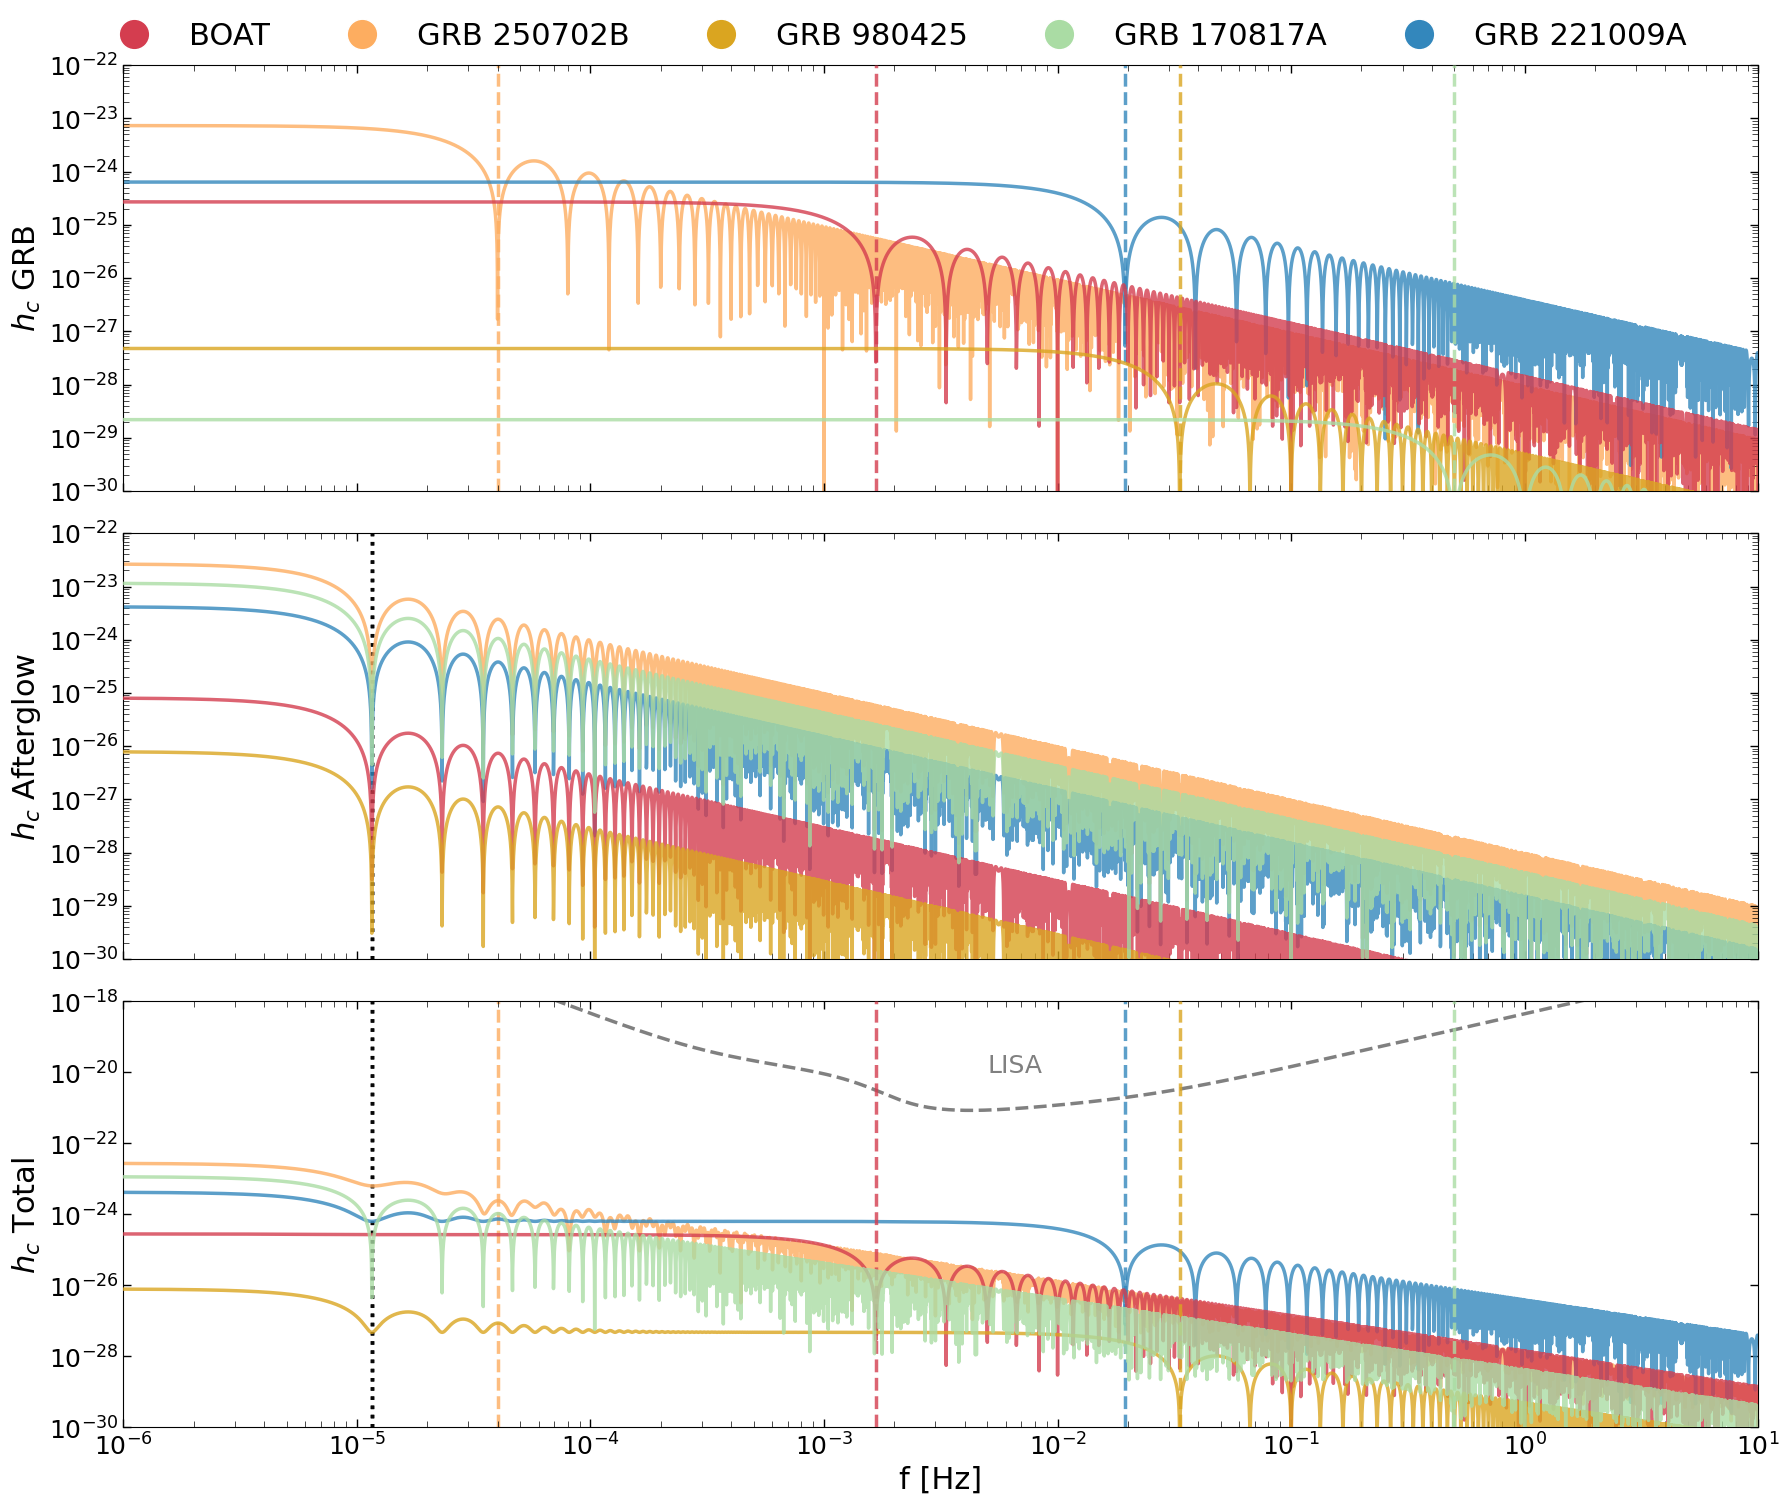

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import Planck18
from matplotlib.lines import Line2D
import astropy.units as u
# Define your GRB parameters
grb_params_data = {
    "BOAT": {
        "E_grb": 1e55, "E_aft": 3e54, "r": 724.0* 1e6,
        "theta_j": 0.014, "theta": np.mean([0.00094, 0.0059]), 'T_90': 600
    },
    "GRB 250702B": {
        "E_grb": 2.2e54, "E_aft": 8e54, "r": Planck18.luminosity_distance(1.036).to_value(u.pc),
        "theta_j": np.deg2rad(0.5), "theta": np.deg2rad(65), 'T_90': 25000
    },
    "GRB 980425": {
        "E_grb": 6e47, "E_aft": 1e49, "r": 36.9* 1e6,
        "theta_j": np.deg2rad(np.mean([18, 31])), "theta": np.deg2rad(np.mean([24, 35])), 'T_90': 30
    },
    "GRB 170817A": {
        "E_grb": 3e46, "E_aft": 10**52.2, "r": 40.0* 1e6,
        "theta_j": 0.3, "theta": np.deg2rad(32), 'T_90': 2
    },
    "GRB 221009A": {
        "E_grb": 7.6e51, "E_aft": 5e52, 'r': 350.0* 1e6, 'T_90': 51.37, 'theta_j': np.deg2rad(0.04),
        'theta': np.deg2rad(30)
    }
}

# Common afterglow timescales
t_dec = 50  # seconds
t_jet_break = 86400  # 1 day in seconds

# Frequency array
f_obs = np.logspace(-8, 1, 10000)

# Prepare figure
fig, axs = plt.subplots(3, 1, figsize=(18, 15), sharex=True)


cmap_vals = [0.1, 0.3, 0.5, 0.7, 0.9]

zorder =[3, 1, 4, 5, 2]

colors = [plt.cm.Spectral(x) for x in cmap_vals]
# replace the third by gold
colors[2] = 'goldenrod'
handles = []
labels = []
for idx, (name, params) in enumerate(grb_params_data.items()):
    t = np.linspace(-1, 5.5*t_jet_break, 100000)
    delta_h, delta_h_GRB, delta_h_aft = utils.grb_afterglow_model(
        t, params["E_grb"], params["T_90"], params["E_aft"], 0.99, t_dec, t_jet_break,
        params["r"], params["theta"], params["theta_j"]
    )
    H_total, H_GRB, H_aft = utils.fft(
        f_obs, delta_h_GRB, params["T_90"], delta_h_aft, t_dec, t_jet_break
    )
    h_c_grb = 2 * f_obs * np.abs(H_GRB)
    h_c_aft = 2 * f_obs * np.abs(H_aft)
    h_c_tot = 2 * f_obs * np.abs(H_total)
    axs[0].plot(f_obs, h_c_grb, color=colors[idx], alpha=0.8, zorder=zorder[idx], lw=2.5)
    axs[0].axvline(1/params["T_90"], color=colors[idx], ls='--', alpha=0.8, zorder = zorder[idx], lw=2.5)
    axs[1].plot(f_obs, h_c_aft, color=colors[idx], alpha=0.8, zorder=zorder[idx], lw=2.5)
    axs[1].axvline(1/(t_jet_break-t_dec), color='k', ls=':', alpha=0.5, zorder=0, lw=2.5)
    axs[2].plot(f_obs, h_c_tot, color=colors[idx], alpha=0.8, zorder=zorder[idx], lw=2.5)
    axs[2].axvline(1/params["T_90"], color=colors[idx], ls='--', alpha=0.8, zorder = zorder[idx], lw=2.5)
    axs[2].axvline(1/(t_jet_break-t_dec), color='k', ls=':', alpha=0.5, zorder=0, lw=2.5)
    # Create a circle handle for the legend
    handles.append(Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[idx], markersize=22))
    labels.append(name)

# LISA sensitivity
import LISA as li
lisa = li.LISA()
S_n = np.sqrt(f_obs * np.abs(lisa.Sn(f_obs)))
axs[2].plot(f_obs, S_n, c='grey', ls='--', zorder=0, lw =2.5)
axs[2].text(5e-3, 1e-20, 'LISA', fontsize=18, color='grey')

# Formatting
for i, ax in enumerate(axs):
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(1e-6, 1e1)
    if i != 2:
        ax.set_ylim(1e-30, 1e-22)
    else:
        ax.set_ylim(1e-30, 1e-18)
    ax.tick_params(axis='both', which='major', labelsize=18, )
    

axs[2].set_xlabel('f [Hz]', fontsize=22)
axs[0].set_ylabel(r'$h_c$ GRB', fontsize=22)
axs[1].set_ylabel(r'$h_c$ Afterglow', fontsize=22)
axs[2].set_ylabel(r'$h_c$ Total',  fontsize=22)




# Add the custom legend at the top
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.01), ncol=len(labels), frameon=False, fontsize=22)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

## Account of the different jet geometries

Norm check = 0.9999999999999868


Integration Jet:   0%|          | 0/50 [00:00<?, ?it/s]

Integration Jet: 100%|██████████| 50/50 [01:42<00:00,  2.04s/it]


Norm check = 0.9999999999999876


Integration Jet: 100%|██████████| 50/50 [01:41<00:00,  2.02s/it]


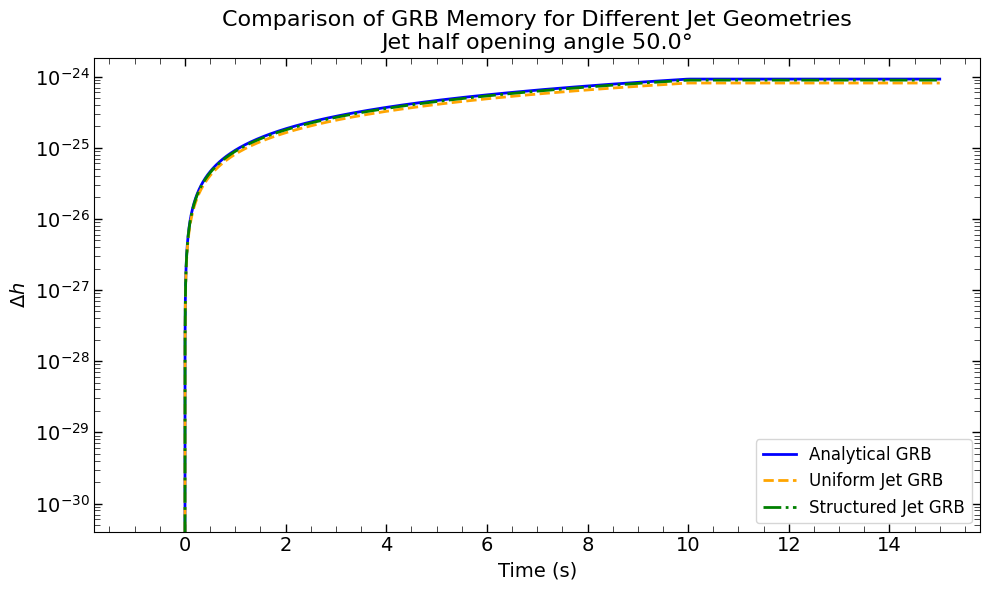

In [177]:
import utils_grb_aft_new as utils
import importlib
importlib.reload(utils)

E_grb = 1e51 # erg
T_90 = 10
d = 100*1e6  # Mpc
beta = 0.99
theta = np.deg2rad(30)  # convert degrees to radians
theta_j = np.deg2rad(50)  # convert degrees to radians
E_aft = 5e52# erg
t_dec = 50
t_jet_break = 86400
t = np.linspace(-1, 1.5*T_90, 100000)
t_jet_break_day = t_jet_break / 86400.0  # convert seconds to days

h_grb, _ , _ = utils.grb_afterglow_model(
    t, E_grb, T_90, 0, beta, t_dec, t_jet_break, d, theta, theta_j
)

h_grb_unif, _ , _ = utils.grb_memory_jet_grb(
    t, E_grb, T_90, 0, beta, t_dec, t_jet_break, d,
    theta, theta_j, Gamma= 100, jet_type='uniform', n_theta=50, n_phi=50
)

h_grb_struc, _ , _ = utils.grb_memory_jet_grb(
    t, E_grb, T_90, 0, beta, t_dec, t_jet_break, d,
    theta, theta_j, Gamma= 100, jet_type='structured', n_theta=50, n_phi=50
)

plt.figure(figsize=(10, 6))
plt.plot(t, h_grb, label='Analytical GRB', color='blue', lw=2)
plt.plot(t, h_grb_unif, label='Uniform Jet GRB', color='orange', lw=2, ls='--')
plt.plot(t, h_grb_struc, label='Structured Jet GRB', color='green', lw=2, ls='-.')
plt.xscale('linear')
plt.yscale('log')
plt.xlabel('Time (s)', fontsize=14)
plt.ylabel(r'$\Delta h$', fontsize=14)
plt.title('Comparison of GRB Memory for Different Jet Geometries' + '\n' + f'Jet half opening angle {np.rad2deg(theta_j)}°', fontsize=16)

plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

Norm check = 0.9999999999999999


Integration Jet:   0%|          | 0/100 [00:00<?, ?it/s]

Integration Jet: 100%|██████████| 100/100 [00:03<00:00, 25.54it/s]


Norm check = 1.0000000000000213


Integration Jet: 100%|██████████| 100/100 [00:03<00:00, 25.86it/s]


...

Integration Jet: 100%|██████████| 100/100 [00:03<00:00, 26.52it/s]


Norm check = 0.9999999999999885


Integration Jet: 100%|██████████| 100/100 [00:03<00:00, 27.01it/s]


Norm check = 1.0000000000000255


Integration Jet: 100%|██████████| 100/100 [00:03<00:00, 27.45it/s]


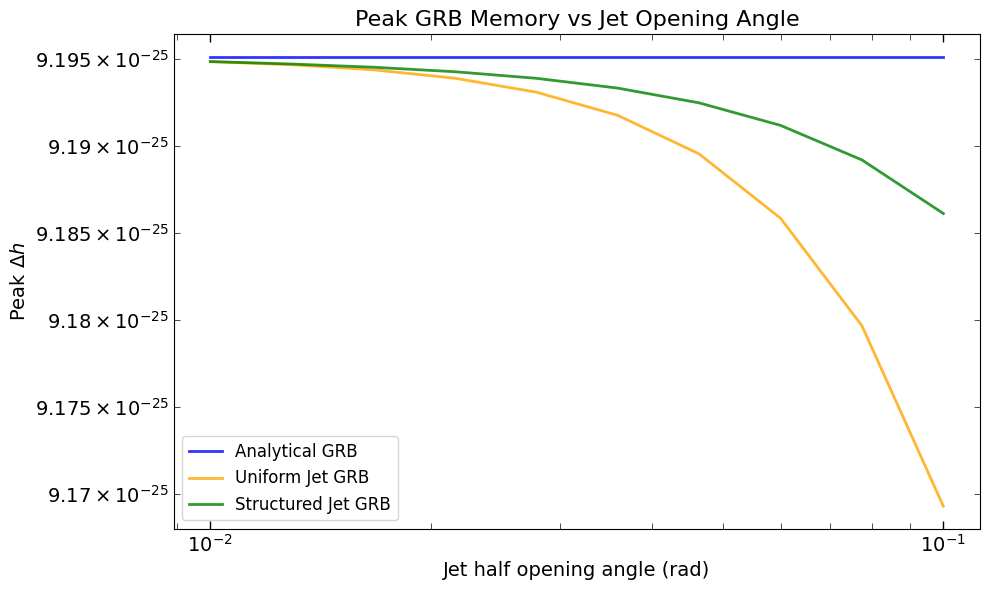

In [191]:
# Evoltuion de delta_h peak en fonction de theta_j
import utils_grb_aft_new as utils
import importlib
importlib.reload(utils)
t = np.linspace(-1, 1.5*T_90, 1000)
theta_j_values = np.logspace(-2, -1, 10)
theta = 0.5
delta_h_peaks = []
E_grb = 1e51 # erg
for theta_j in theta_j_values:

    h_grb, _ , _ = utils.grb_afterglow_model(
        t, E_grb, T_90, 0, beta, t_dec, t_jet_break, d, theta, 0
    )
    delta_h_peaks.append(np.max(h_grb))
    # uniform jet
    h_grb_unif, _ , _ = utils.grb_memory_jet_grb(
        t, E_grb, T_90, 0, beta, t_dec, t_jet_break, d,
        theta, theta_j, Gamma= 100, jet_type='uniform', n_theta=100, n_phi=100
    )
    delta_h_peaks.append(np.max(h_grb_unif))
    # structured jet
    h_grb_struc, _ , _ = utils.grb_memory_jet_grb(
        t, E_grb, T_90, 0, beta, t_dec, t_jet_break, d,
        theta, theta_j, Gamma= 100, jet_type='structured', n_theta=100, n_phi=100
    )
    delta_h_peaks.append(np.max(h_grb_struc))
plt.figure(figsize=(10, 6))
plt.plot((theta_j_values), delta_h_peaks[0::3], label='Analytical GRB', color='blue', lw=2, alpha=0.8)
plt.plot((theta_j_values), delta_h_peaks[1::3], label='Uniform Jet GRB', color='orange', lw=2, ls='-', alpha=0.8)
plt.plot((theta_j_values), delta_h_peaks[2::3], label='Structured Jet GRB', color='green', lw=2, ls='-', alpha=0.8)
plt.xscale('log')
plt.yscale('log')

plt.xlabel('Jet half opening angle (rad)', fontsize=14)
plt.ylabel(r'Peak $\Delta h$', fontsize=14)
plt.title('Peak GRB Memory vs Jet Opening Angle', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

---

## Check the max amplitude compared to the opening angle and the viewing angle for the different jet geometries

### Case 1:

$\Gamma^{-1} < \theta_j < \theta_v$

In [198]:
import numpy as np
from tqdm import tqdm
import utils_grb_aft_new as utils
import importlib
importlib.reload(utils)
# Paramètres constants
E_total = 1e51  # Énergie totale constante comme dans l'article
Gamma = 100     # Valeur typique de l'article
theta_j_values = np.logspace(-2, 0, 13)  # de 0.01 rad à ~57 deg
d_pc = 100 * 1e6  # distance constante de 100 Mpc
# On définit une plage d'angles d'observation pour chercher le pic global
theta_v_range = np.linspace(0, np.pi/2, 50) 

h_peak_global_unif = []
h_peak_global_struc = []

for theta_0 in theta_j_values:
    # --- JET UNIFORME ---
    amplitudes_unif = []
    # On cherche l'angle theta_v qui donne le maximum
    for tv in theta_v_range:
        # On ne calcule que la valeur scalaire delta_h_jet_grb (l'amplitude finale)
        _, dh_max, _ = utils.grb_memory_jet_grb(
            t, E_total, T_90, 0, beta, t_dec, t_jet_break, d_pc,
            tv, theta_0, Gamma, jet_type='uniform', n_theta=50, n_phi=50
        )
        amplitudes_unif.append(dh_max)
    
    h_peak_global_unif.append(max(amplitudes_unif))

    # --- JET STRUCTURÉ ---
    amplitudes_struc = []
    for tv in theta_v_range:
        _, dh_max, _ = utils.grb_memory_jet_grb(
            t, E_total, T_90, 0, beta, t_dec, t_jet_break, d_pc,
            tv, theta_0, Gamma, jet_type='structured', n_theta=50, n_phi=50
        )
        amplitudes_struc.append(dh_max)
    
    h_peak_global_struc.append(max(amplitudes_struc))
    # Point jet case (as before)
    delta_h_peaks = []
    for theta_j in theta_j_values:
        peaks = []
        for tv in theta_v_range:
            _, h_grb , _ = utils.grb_afterglow_model(
                t, E_grb, T_90, 0, beta, t_dec, t_jet_break, d, tv, 0
            )
            peaks.append(h_grb)
        delta_h_peaks.append(np.max(peaks))  # ou np.max(np.abs(peaks)) si besoin
    


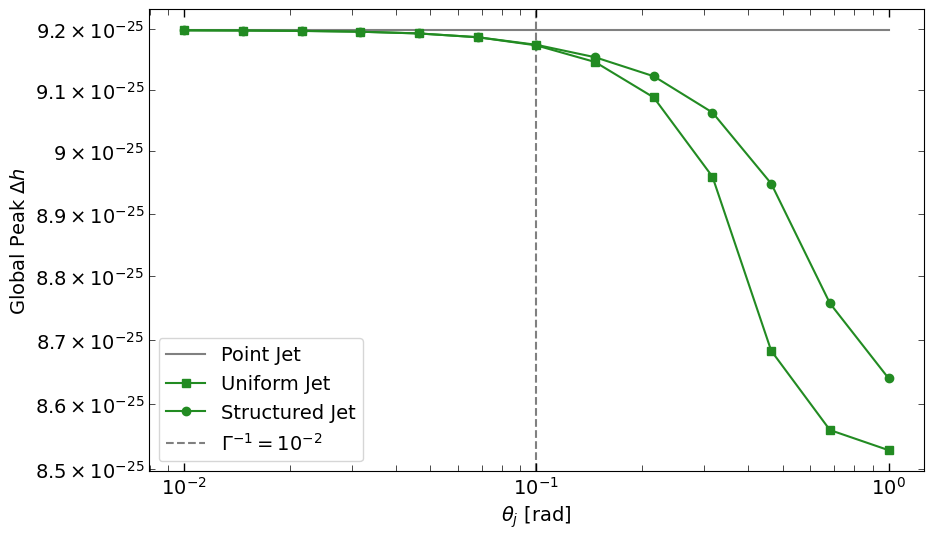

In [211]:
# Affichage
plt.figure(figsize=(10, 6))
plt.loglog(theta_j_values, delta_h_peaks, '-', label='Point Jet', color = 'grey', zorder=1)
plt.loglog(theta_j_values, h_peak_global_unif, '-s', label='Uniform Jet', color = 'forestgreen', zorder=2 )
plt.loglog(theta_j_values, h_peak_global_struc, '-o', label='Structured Jet', color = 'forestgreen', zorder=2)
# add 1/ Gamma line
plt.axvline(1/Gamma, color='grey', ls='--', label=r'$\Gamma^{-1} = 10^{-2} $', zorder=0)
plt.xlabel(r'$\theta_j$ [rad]', fontsize=14)
plt.ylabel(r'Global Peak $\Delta h$', fontsize=14)
plt.legend(loc='lower left', fontsize=14)

### Case 2:
$\theta_j <\Gamma^{-1}  < \theta_v$

In [209]:
import numpy as np
from tqdm import tqdm
import utils_grb_aft_new as utils
import importlib
importlib.reload(utils)
# Paramètres constants
E_total = 1e51  # Énergie totale constante comme dans l'article
Gamma = 10    
theta_j_values = np.logspace(-2, 0, 13)  # de 0.01 rad à ~57 deg
d_pc = 100 * 1e6  # distance constante de 100 Mpc
# On définit une plage d'angles d'observation pour chercher le pic global
theta_v_range = np.linspace(0, np.pi/2, 50) 

h_peak_global_unif = []
h_peak_global_struc = []

for theta_0 in theta_j_values:
    # --- JET UNIFORME ---
    amplitudes_unif = []
    # On cherche l'angle theta_v qui donne le maximum
    for tv in theta_v_range:
        # On ne calcule que la valeur scalaire delta_h_jet_grb (l'amplitude finale)
        _, dh_max, _ = utils.grb_memory_jet_grb(
            t, E_total, T_90, 0, beta, t_dec, t_jet_break, d_pc,
            tv, theta_0, Gamma, jet_type='uniform', n_theta=50, n_phi=50
        )
        amplitudes_unif.append(dh_max)
    
    h_peak_global_unif.append(max(amplitudes_unif))

    # --- JET STRUCTURÉ ---
    amplitudes_struc = []
    for tv in theta_v_range:
        _, dh_max, _ = utils.grb_memory_jet_grb(
            t, E_total, T_90, 0, beta, t_dec, t_jet_break, d_pc,
            tv, theta_0, Gamma, jet_type='structured', n_theta=50, n_phi=50
        )
        amplitudes_struc.append(dh_max)
    
    h_peak_global_struc.append(max(amplitudes_struc))
    # Point jet case (as before)
    delta_h_peaks = []
    for theta_j in theta_j_values:
        peaks = []
        for tv in theta_v_range:
            _, h_grb , _ = utils.grb_afterglow_model(
                t, E_grb, T_90, 0, beta, t_dec, t_jet_break, d, tv, 0
            )
            peaks.append(h_grb)
        delta_h_peaks.append(np.max(peaks))  # ou np.max(np.abs(peaks)) si besoin
    


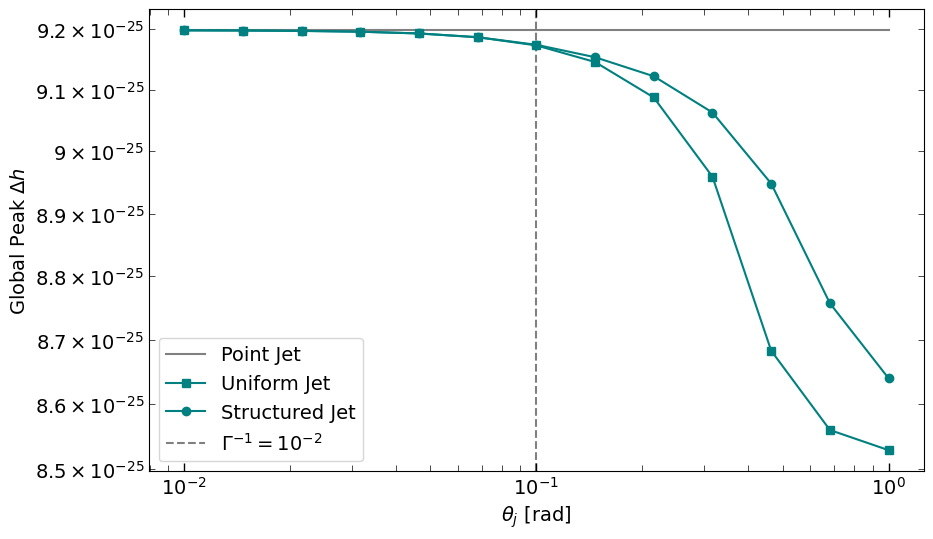

In [210]:
# Affichage
plt.figure(figsize=(10, 6))
plt.loglog(theta_j_values, delta_h_peaks, '-', label='Point Jet', color = 'grey', zorder=1)
plt.loglog(theta_j_values, h_peak_global_unif, '-s', label='Uniform Jet', color = 'teal', zorder=2 )
plt.loglog(theta_j_values, h_peak_global_struc, '-o', label='Structured Jet', color = 'teal', zorder=2)
# add 1/ Gamma line
plt.axvline(1/Gamma, color='grey', ls='--', label=r'$\Gamma^{-1} = 10^{-2} $', zorder=0)
plt.xlabel(r'$\theta_j$ [rad]', fontsize=14)
plt.ylabel(r'Global Peak $\Delta h$', fontsize=14)
plt.legend(loc='best', fontsize=14)

Both cases 

In [214]:
import numpy as np
from tqdm import tqdm
import utils_grb_aft_new as utils
import importlib
importlib.reload(utils)
# Paramètres constants
E_total = 1e51  # Énergie totale constante comme dans l'article
Gamma = 100     # Valeur typique de l'article
theta_j_values = np.logspace(-2, 0, 13)  # de 0.01 rad à ~57 deg
d_pc = 100 * 1e6  # distance constante de 100 Mpc
# On définit une plage d'angles d'observation pour chercher le pic global
theta_v_range = np.linspace(0, np.pi/2, 50) 

h_peak_global_unif = []
h_peak_global_struc_low = []
h_peak_global_struc_high = []
for theta_0 in theta_j_values:
    # --- JET UNIFORME ---
    amplitudes_unif = []
    # On cherche l'angle theta_v qui donne le maximum
    for tv in theta_v_range:
        # On ne calcule que la valeur scalaire delta_h_jet_grb (l'amplitude finale)
        _, dh_max, _ = utils.grb_memory_jet_grb(
            t, E_total, T_90, 0, beta, t_dec, t_jet_break, d_pc,
            tv, theta_0, Gamma, jet_type='uniform', n_theta=50, n_phi=50
        )
        amplitudes_unif.append(dh_max)
    
    h_peak_global_unif.append(max(amplitudes_unif))

    # --- JET STRUCTURÉ Gamma = 100 ---
    amplitudes_struc_high = []
    for tv in theta_v_range:
        _, dh_max, _ = utils.grb_memory_jet_grb(
            t, E_total, T_90, 0, beta, t_dec, t_jet_break, d_pc,
            tv, theta_0, 100, jet_type='structured', n_theta=50, n_phi=50
        )
        amplitudes_struc_high.append(dh_max)
    
    h_peak_global_struc_high.append(max(amplitudes_struc_high))
    
    # --- JET STRUCTURÉ Gamma = 10 ---
    amplitudes_struc_low = []
    for tv in theta_v_range:
        _, dh_max, _ = utils.grb_memory_jet_grb(
            t, E_total, T_90, 0, beta, t_dec, t_jet_break, d_pc,
            tv, theta_0, 10, jet_type='structured', n_theta=50, n_phi=50
        )
        amplitudes_struc_low.append(dh_max)
    
    h_peak_global_struc_low.append(max(amplitudes_struc_low))
    # Point jet case (as before)
    delta_h_peaks = []
    for theta_j in theta_j_values:
        peaks = []
        for tv in theta_v_range:
            _, h_grb , _ = utils.grb_afterglow_model(
                t, E_grb, T_90, 0, beta, t_dec, t_jet_break, d, tv, 0
            )
            peaks.append(h_grb)
        delta_h_peaks.append(np.max(peaks))  # ou np.max(np.abs(peaks)) si besoin
    

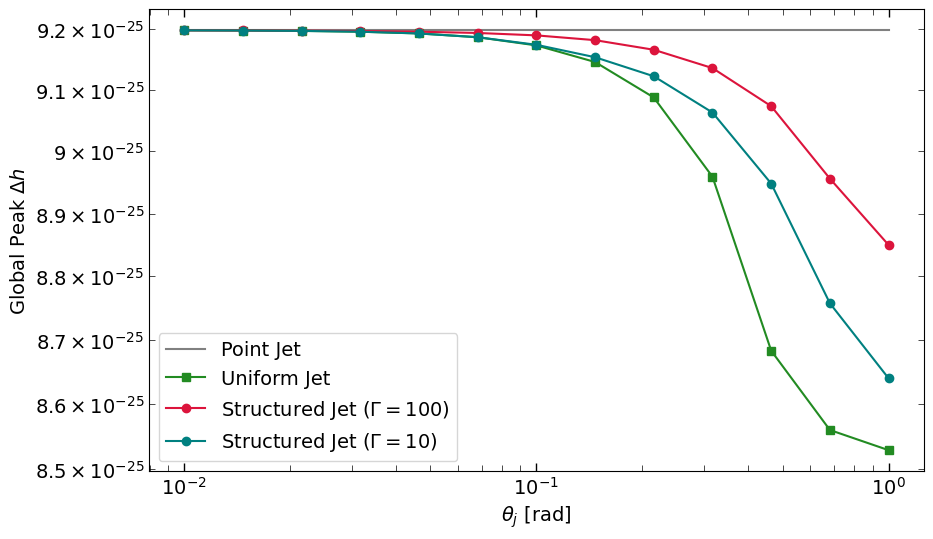

In [215]:
# Affichage
plt.figure(figsize=(10, 6))
plt.loglog(theta_j_values, delta_h_peaks, '-', label='Point Jet', color = 'grey', zorder=1)
plt.loglog(theta_j_values, h_peak_global_unif, '-s', label='Uniform Jet', color = 'forestgreen', zorder=2 )
plt.loglog(theta_j_values, h_peak_global_struc_high, '-o', label='Structured Jet ($\Gamma = 100$)', color = 'crimson', zorder=2)
plt.loglog(theta_j_values, h_peak_global_struc_low, '-o', label='Structured Jet ($\Gamma = 10$)', color = 'teal', zorder=2)


plt.xlabel(r'$\theta_j$ [rad]', fontsize=14)
plt.ylabel(r'Global Peak $\Delta h$', fontsize=14)
plt.legend(loc='best', fontsize=14)

### Low $\theta_v$ case

In [ ]:
import numpy as np
from tqdm import tqdm
import utils_grb_aft_new as utils
import importlib
importlib.reload(utils)
# Paramètres constants
E_total = 1e51  # Énergie totale constante comme dans l'article
Gamma = 100    
theta_j_values = np.logspace(-2, 0, 13)  # de 0.01 rad à ~57 deg
d_pc = 100 * 1e6  # distance constante de 100 Mpc
# On définit une plage d'angles d'observation pour chercher le pic global
theta_v_range = np.linspace(0, np.deg2rad(10), 50) 

h_peak_global_unif = []
h_peak_global_struc = []

for theta_0 in theta_j_values:
    # --- JET UNIFORME ---
    amplitudes_unif = []
    # On cherche l'angle theta_v qui donne le maximum
    for tv in theta_v_range:
        # On ne calcule que la valeur scalaire delta_h_jet_grb (l'amplitude finale)
        _, dh_max, _ = utils.grb_memory_jet_grb(
            t, E_total, T_90, 0, beta, t_dec, t_jet_break, d_pc,
            tv, theta_0, Gamma, jet_type='uniform', n_theta=50, n_phi=50
        )
        amplitudes_unif.append(dh_max)
    
    h_peak_global_unif.append(max(amplitudes_unif))

    # --- JET STRUCTURÉ ---
    amplitudes_struc = []
    for tv in theta_v_range:
        _, dh_max, _ = utils.grb_memory_jet_grb(
            t, E_total, T_90, 0, beta, t_dec, t_jet_break, d_pc,
            tv, theta_0, Gamma, jet_type='structured', n_theta=50, n_phi=50
        )
        amplitudes_struc.append(dh_max)
    
    h_peak_global_struc.append(max(amplitudes_struc))
    # Point jet case (as before)
    delta_h_peaks = []
    for theta_j in theta_j_values:
        peaks = []
        for tv in theta_v_range:
            _, h_grb , _ = utils.grb_afterglow_model(
                t, E_grb, T_90, 0, beta, t_dec, t_jet_break, d, tv, 0
            )
            peaks.append(h_grb)
        delta_h_peaks.append(np.max(peaks))  # ou np.max(np.abs(peaks)) si besoin
    


In [ ]:
# Affichage
plt.figure(figsize=(10, 6))
plt.loglog(theta_j_values, delta_h_peaks, '-', label='Point Jet', color = 'grey', zorder=1)
plt.loglog(theta_j_values, h_peak_global_unif, '-s', label='Uniform Jet', color = 'crimson', zorder=2 )
plt.loglog(theta_j_values, h_peak_global_struc, '-o', label='Structured Jet', color = 'crimson', zorder=2)
# add 1/ Gamma line
plt.axvline(1/Gamma, color='grey', ls='--', label=r'$\Gamma^{-1} = 10^{-2} $', zorder=0)
plt.xlabel(r'$\theta_j$ [rad]', fontsize=14)
plt.ylabel(r'Global Peak $\Delta h$', fontsize=14)
plt.legend(loc='lower left', fontsize=14)

---

In [17]:
x = 0.01 # rad
x_deg = np.rad2deg(x)
print(f"{x} radians is equal to {x_deg} degrees")

0.01 radians is equal to 0.5729577951308232 degrees


In [160]:
def plot_jet_disk_f_theta(theta_0, Gamma=100, jet_type='uniform', n=1000):
    """
    Affiche f(theta) dans le disque du jet (projection cartésienne) avec annotation theta_0 et (optionnel) 1/Gamma.
    """

    # only take half of the cmap
    cmap = plt.get_cmap('bone')
    cmap_part = cmap(np.linspace(0., 1, 256))  # portion de 20% à 80%
    from matplotlib.colors import ListedColormap
    cmap = ListedColormap(cmap_part)
    
    theta = np.linspace(0, np.pi, n)
    phi = np.linspace(0, 2*np.pi, n)
    Theta, Phi = np.meshgrid(theta, phi)
    from utils_grb_aft_new import f_theta
    F = f_theta(Theta, theta_0=theta_0, Gamma=Gamma, jet_type=jet_type)
    X = Theta * np.cos(Phi)
    Y = Theta * np.sin(Phi)

    fig, ax = plt.subplots(figsize=(7,7))
    pcm = ax.pcolormesh(X, Y, F, shading='auto', cmap=cmap)
    plt.colorbar(pcm, ax=ax, label=r'$f(\theta)$', pad=0.05, aspect=20, shrink=0.75)
    ax.set_xlabel('x (rad)')
    ax.set_ylabel('y (rad)')
    # add a maj for jet_type
    jet_type = jet_type.capitalize()
    ax.set_title(rf"{jet_type} jet, $\theta_0={np.rad2deg(theta_0):.1f}^\circ$, $\Gamma={Gamma}$")
    ax.set_aspect('equal')
    # set lim
    ax.set_xlim(-theta_0*1.2, theta_0*1.2)
    ax.set_ylim(-theta_0*1.2, theta_0*1.2)
    plt.tight_layout()

    # Double flèche pour theta_0
    r = theta_0
    ax.annotate('', xy=(r, -0.0), xytext=(0, -0.0),
                arrowprops=dict(arrowstyle='<->', color='red', lw=2))
    ax.text(r/2, -0.05*r, r'$\theta_0$', color='red', fontsize=16, ha='center', va='top')

    # Si structured, double flèche pour 1/Gamma
    if jet_type.lower() == 'structured':
        theta_core = 1.0 / Gamma
        ax.annotate('', xy=(theta_core, -0.05), xytext=(0, -0.05),
                    arrowprops=dict(arrowstyle='<->', color='orange', lw=2))
        ax.text(theta_core/2, -0.22*r, r'$\Gamma^{-1}$', color='orange', fontsize=16, ha='center', va='top')

    plt.show()

/tmp/ipykernel_1669/1639993810.py:21: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm = ax.pcolormesh(X, Y, F, shading='auto', cmap=cmap)


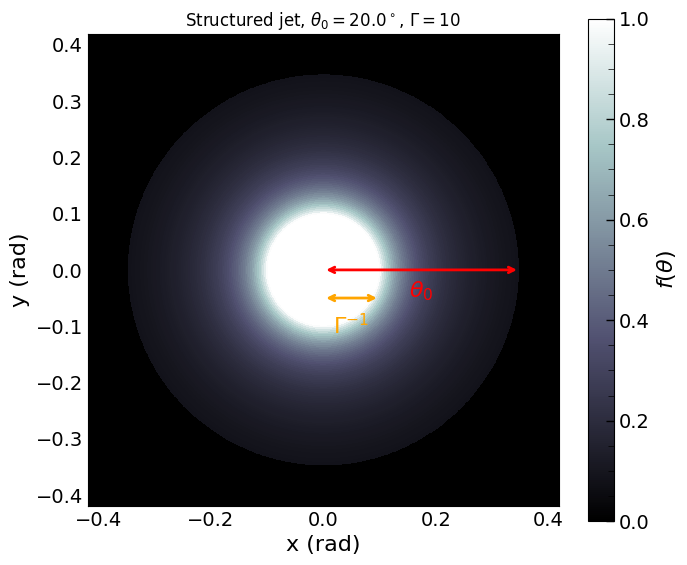

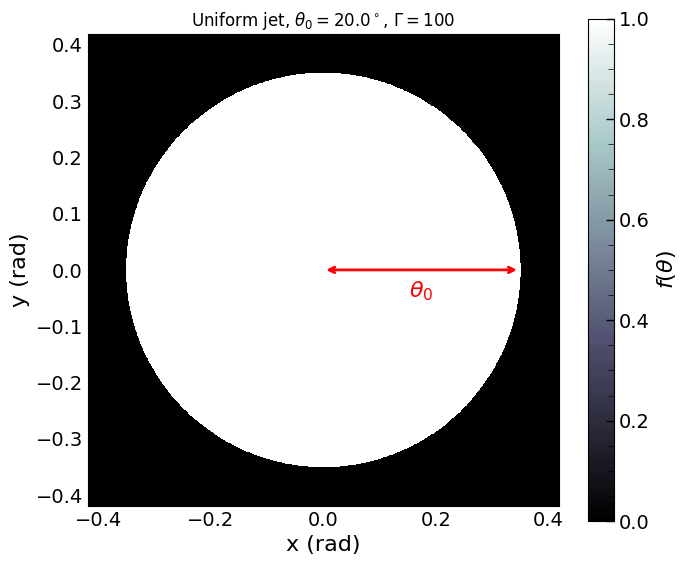

In [161]:
plot_jet_disk_f_theta(theta_0=np.deg2rad(20), Gamma=10, jet_type='structured')
plot_jet_disk_f_theta(theta_0=np.deg2rad(20), Gamma=100, jet_type='uniform')

### Heatmap of the memory effect for different jet geometries (top-hat, structured, etc.) and different observer angles. 

This would allow us to see how the memory effect changes with the jet structure and the observer's line of sight more clearly.

! to test on the server - too long to run on the local machine

In [196]:
# Paramètres
E_total = 1e51
Gamma = 100
d_pc = 100 * 1e6
T_90 = 10
beta = 0.99
t_dec = 50
t_jet_break = 86400
t = np.linspace(-1, 1.5*T_90, 1000)

theta_j_values = np.logspace(-2, 0, 30)  # 0.01 à 1 rad
theta_v_values = np.linspace(0, np.pi/2, 40)  # 0 à 90°
delta_h_peak_unif = np.zeros((len(theta_j_values), len(theta_v_values)))
delta_h_peak_struc = np.zeros((len(theta_j_values), len(theta_v_values)))

for i, theta_j in enumerate(tqdm(theta_j_values, desc="theta_j")):
    for j, theta_v in enumerate(theta_v_values):
        # Uniform
        _, dh_max_unif, _ = utils.grb_memory_jet_grb(
            t, E_total, T_90, 0, beta, t_dec, t_jet_break, d_pc,
            theta_v, theta_j, Gamma, jet_type='uniform', n_theta=40, n_phi=40
        )
        delta_h_peak_unif[i, j] = dh_max_unif
        # Structuré
        _, dh_max_struc, _ = utils.grb_memory_jet_grb(
            t, E_total, T_90, 0, beta, t_dec, t_jet_break, d_pc,
            theta_v, theta_j, Gamma, jet_type='structured', n_theta=40, n_phi=40
        )
        delta_h_peak_struc[i, j] = dh_max_struc

# Affichage heatmap uniforme
plt.figure(figsize=(10, 6))
plt.title("Uniform Jet: Peak $\Delta h$ vs $\\theta_v$ and $\\theta_j$")
plt.xlabel(r"$\theta_v$ (rad)")
plt.ylabel(r"$\theta_j$ (rad)")
plt.pcolormesh(theta_v_values, theta_j_values, delta_h_peak_unif, shading='auto', cmap='viridis')
plt.colorbar(label="Peak $\Delta h$")
plt.yscale('log')
plt.show()

# Affichage heatmap structuré
plt.figure(figsize=(10, 6))
plt.title("Structured Jet: Peak $\Delta h$ vs $\\theta_v$ and $\\theta_j$")
plt.xlabel(r"$\theta_v$ (rad)")
plt.ylabel(r"$\theta_j$ (rad)")
plt.pcolormesh(theta_v_values, theta_j_values, delta_h_peak_struc, shading='auto', cmap='magma')
plt.colorbar(label="Peak $\Delta h$")
plt.yscale('log')
plt.show()

theta_j:   0%|          | 0/30 [00:00<?, ?it/s]

theta_j:  47%|████▋     | 14/30 [12:39<14:28, 54.27s/it]


KeyboardInterrupt: 